# Basic Data Analysis Workflow

This notebook demonstrates how to analyze a dataset using pandas and matplotlib/seaborn. Steps include:
1. Loading the data
2. Inspecting the data
3. Visualizing distributions
4. Checking for missing values
5. Summarizing categorical and numerical columns

In [1]:
import pandas as pd

# 1. Load your data (update the filename if needed)
file_path = "train_araCovid_sentiment.tsv"
df = pd.read_csv(file_path, encoding='utf-8', sep='\t')
df.head()

,Unnamed: 0,Text,sentiment
0,0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,Positive
1,1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,Positive
2,2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,Positive
3,3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,Positive
4,4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,Positive


In [ ]:
# Shuffle the dataset and print the first 5 comments
df_shuffled = df.sample( random_state=42).reset_index(drop=True)
df_shuffled.head()


,Unnamed: 0,Text,sentiment
0,949,😜 بعض الناس يرفض المصافحة خايف من كورونا 🤔 لك...,Positive


In [16]:
# Sample 2 comments from each sentiment and combine into a single DataFrame
sampled_df = df.groupby('sentiment').apply(lambda x: x.sample(2, random_state=42)).reset_index(drop=True)
# Show the sampled DataFrame with only 'Text' and 'sentiment' columns
result_df = sampled_df[['Text', 'sentiment']]
# Shuffle the result_df to randomize the order of comments
result_df = result_df.sample(frac=1, random_state=42).reset_index(drop=True)
result_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_19796\498491961.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('sentiment').apply(lambda x: x.sample(2, random_state=42)).reset_index(drop=True)


,Text,sentiment
0,يا عمي نحن بشر بلبنان او برغش ؟؟؟؟ لك صرلنا سن...,Negative
1,يارب كورونا يروح منها بسرعه 😭,Negative
2,#فيروس_كورونا_المستجد بإذن الله 🤲 ستختفي الكم...,Positive
3,اللهم بقدرتك تجعل اشئ(كن فيكون) اللهم في اخر ...,Neutral
4,@Salamaroshdy78 ههههههههههه... ياريت.. دول أخط...,Positive
5,@shaamteem @Kalmuqdad @Oq1Jsy7DPyolD7d @SRoudi...,Neutral


In [3]:
# 2. Inspect the data
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.info())
print(df.describe(include='all'))

Shape: (4128, 3)
Columns: Index(['Unnamed: 0', 'Text', 'sentiment'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4128 non-null   int64 
 1   Text        4128 non-null   object
 2   sentiment   4128 non-null   object
dtypes: int64(1), object(2)
memory usage: 96.9+ KB
None
         Unnamed: 0                                               Text  \
count   4128.000000                                               4128   
unique          NaN                                               4128   
top             NaN  *علاج ڤايروس الكورونا*   كل يوم الصبح الواحد ي...   
freq            NaN                                                  1   
mean    2063.500000                                                NaN   
std     1191.795284                                                NaN   
min        0.000000                

## DataFrame Summary Analysis

- **Shape:** The dataset contains 4128 rows and 3 columns, indicating 4128 comments.
- **Columns:** 
  - `Unnamed: 0`: Likely an index column from saving/loading the file.
  - `Text`: The actual comment text (all unique, as shown by `unique=4128`).
  - `sentiment`: The sentiment label for each comment.

- **Data Types:** 
  - `Unnamed: 0` is integer (probably just a row index).
  - `Text` and `sentiment` are objects (strings).

- **Missing Values:** There are no missing values in any column (`4128 non-null` for all).

- **Text Column:** Each comment is unique (`unique=4128`, `freq=1`), so there are no duplicates in the text.

- **Sentiment Column:** There are 3 unique sentiment classes. The most frequent is `Neutral` (1600 out of 4128, about 39%).

- **Index Column:** The `Unnamed: 0` column ranges from 0 to 4127, confirming it is just a row index.

**Conclusion:**  
The dataset is clean, with no missing values or duplicate comments. Sentiment distribution is imbalanced, with Neutral being the most common. The data is ready for further analysis or modeling.

In [4]:
# Prepare the words list if not already defined
words = " ".join(df['Text'].astype(str)).split()

# Print the number of unique words in the corpus
unique_words = set(words)
print(f"Number of unique words: {len(unique_words)}")
print("Sample unique words:", list(unique_words)[:20])

Number of unique words: 20510
Sample unique words: ['الشرق', 'أحزنني', '#الواد_نشات_الطيز', '😖', 'المواطن', 'صارت', 'البزر.#كورونا_لبنان', '#فيروس_كورونا_المستجد', 'الطحين', 'ماقول', 'حيت', 'متعه', 'منكم', 'سنحيي', 'ذنبك', 'وأنزع', 'برؤيتك', 'ورحم', 'اي', 'نفسهم']


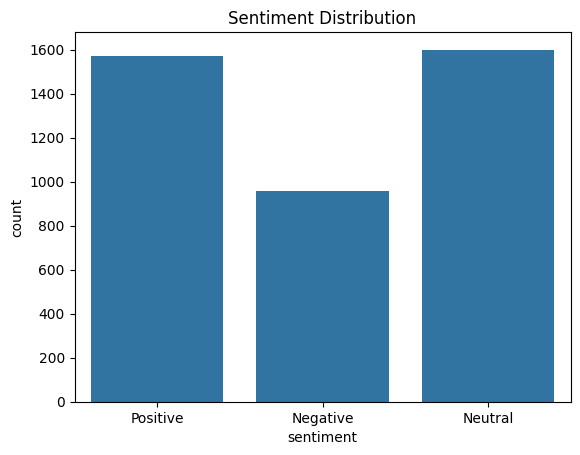

In [5]:
# 4. Visualize categorical columns (e.g., sentiment distribution)
import matplotlib.pyplot as plt
import seaborn as sns

if 'sentiment' in df.columns:
    sns.countplot(data=df, x='sentiment')
    plt.title('Sentiment Distribution')
    plt.show()

## Analysis of the Sentiment Distribution Chart

The bar chart shows the distribution of sentiment labels in the dataset:

- **Neutral** and **Positive** sentiments are almost equally represented, each with about 1,600 comments.
- **Negative** sentiment is less frequent, with fewer than 1,000 comments.
- This indicates a class imbalance: Neutral and Positive are overrepresented compared to Negative.
- Such imbalance should be considered in modeling (e.g., using class weights or resampling) to avoid bias toward the majority classes.
- The dataset overall contains a good number of samples for each class, but more Negative samples could improve model robustness.

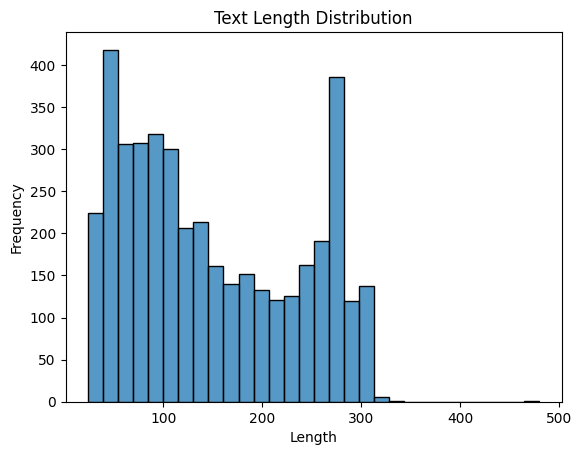

In [6]:
# 5. Visualize text length distribution (if you have a text column)
if 'Text' in df.columns:
    df['text_length'] = df['Text'].astype(str).apply(len)
    sns.histplot(df['text_length'], bins=30)
    plt.title('Text Length Distribution')
    plt.xlabel('Length')
    plt.ylabel('Frequency')
    plt.show()

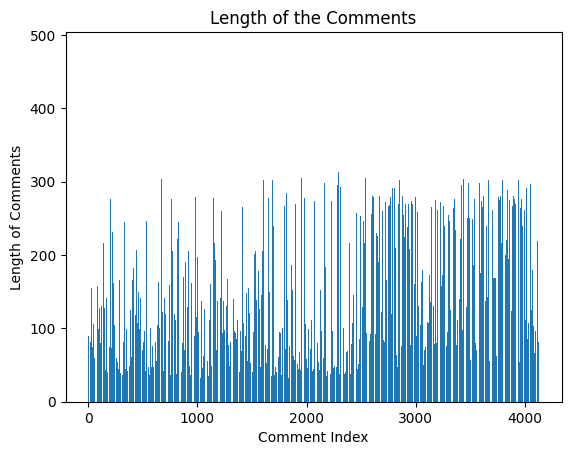

Average length of comments: 149.53 characters


In [7]:
# Extract the lengths of the first 100 cleaned comments
lengths = [len(comment) for comment in df['Text'][:4128]]

# Plot the lengths
plt.bar(range(1, 4129), lengths)
plt.xlabel('Comment Index')
plt.ylabel('Length of Comments')
plt.title('Length of the Comments')
plt.show()

# Calculate the average length of the cleaned comments
average_length = sum(lengths) / len(lengths)
print(f"Average length of comments: {average_length:.2f} characters")

## Analysis of the "Length of the First 4128 Cleaned Comments" Graph

- **Distribution:** The bar chart displays the length (in characters) of each comment in the dataset, indexed from 1 to 4128.
- **Variation:** There is significant variability in comment lengths, ranging from very short (under 50 characters) to quite long (over 300 characters).
- **Outliers:** Occasional spikes indicate the presence of unusually long comments, but most comments cluster below 200 characters.
- **Average Length:** The average comment length is approximately 150 characters, as previously calculated.
- **Implications:** The wide range in text lengths suggests the need for careful preprocessing (e.g., padding or truncation) when preparing data for machine learning models. The presence of both short and long comments may impact model performance and should be considered in feature engineering and model selection.

In [8]:
# Count comments with more than 150 words
if 'Cleaned_text' in df.columns:
	count_long_comments = df['Cleaned_text'].astype(str).apply(lambda x: len(x.split()) > 150).sum()
	print(f"Number of comments with more than 150 words: {count_long_comments}")

## More Data Analysis

Let's add more analysis:
- Sentiment proportions
- Most frequent words
- Average text length per sentiment
- Boxplot of text lengths by sentiment
- Word cloud for each sentiment

In [9]:
# Sentiment proportions
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts(normalize=True))

sentiment
Neutral     0.387597
Positive    0.380572
Negative    0.231831
Name: proportion, dtype: float64


In [10]:
# Most frequent words in all texts
from collections import Counter

if 'Text' in df.columns:
    words = " ".join(df['Text'].astype(str)).split()
    most_common = Counter(words).most_common(20)
    print("Most common words:", most_common)

Most common words: [('الله', 1934), ('من', 1876), ('كورونا', 1800), ('في', 1246), ('و', 1071), ('لا', 1062), ('يلعن', 775), ('الكورونا', 738), ('#كورونا', 611), ('على', 601), ('اللهم', 553), ('ما', 468), ('ولا', 438), ('-', 412), ('.', 409), ('،', 405), ('يا', 381), ('كل', 368), ('..', 353), ('هذا', 346)]


In [11]:
# Average text length per sentiment
if 'sentiment' in df.columns and 'Text' in df.columns:
    df['text_length'] = df['Text'].astype(str).apply(len)
    print(df.groupby('sentiment')['text_length'].mean())

sentiment
Negative    119.665622
Neutral     181.913750
Positive    134.740929
Name: text_length, dtype: float64


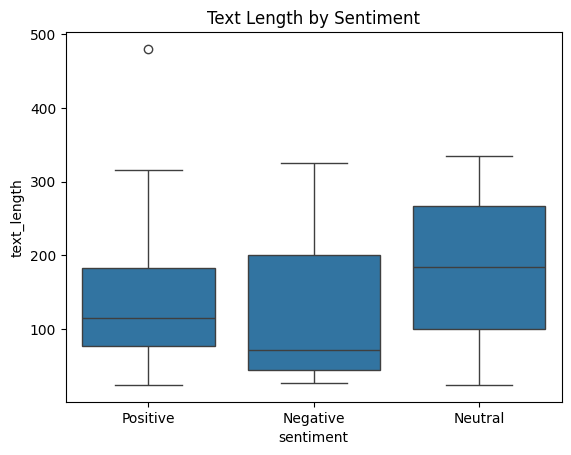

In [12]:
# Boxplot of text lengths by sentiment
if 'sentiment' in df.columns and 'Text' in df.columns:
    import seaborn as sns
    import matplotlib.pyplot as plt
    sns.boxplot(x='sentiment', y='text_length', data=df)
    plt.title('Text Length by Sentiment')
    plt.show()

## Analysis of the Text Length by Sentiment Boxplot

The boxplot visualizes the distribution of text lengths for each sentiment class (Positive, Negative, Neutral):

- **Neutral comments** tend to be longer on average, with a higher median and a wider interquartile range compared to Positive and Negative comments.
- **Negative comments** show a wide spread, but their median is lower than Neutral and slightly higher than Positive.
- **Positive comments** generally have shorter text lengths, with a lower median and a more compact distribution.
- There are some outliers, especially in the Positive class, indicating a few very long comments.
- The overall trend suggests that Neutral comments are more detailed or descriptive, while Positive and Negative comments are often shorter.

This information can help in preprocessing (e.g., choosing sequence length for models) and understanding user behavior in sentiment expression.

In [13]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenize the text in each row of the 'Text' column
df['tokens'] = df['Text'].astype(str).apply(nltk.word_tokenize)

# Display the first few entries with their tokens
df[['Text', 'tokens']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Text,tokens
0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,"[*, علاج, ڤايروس, الكورونا, *, كل, يوم, الصبح,..."
1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,"[ههههه, هذا, مكان, اخطر, من, كورونا, فايروس, ...."
2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,"[خايفه, يجيبوا, لقاح, الكورونا, وما, يكفينا, و..."
3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,"[الطواقي, وشخبار, الطرد, لحل, يطلعون, اشاعات, ..."
4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,"[@, Waleed_Albashaa, هههههههه, انتظر, بعد, ما,..."


In [14]:
print(df['tokens'].explode().head(100).tolist())

['*', 'علاج', 'ڤايروس', 'الكورونا', '*', 'كل', 'يوم', 'الصبح', 'الواحد', 'يقرط', 'ثلات', 'حبات', 'ثوم،', 'ومع', 'إنو', 'الثوم', 'ما', 'إله', 'علاقة', 'بڤايروس', 'الكورونا', 'بس', 'هكذا', 'بتضمن', 'لا', 'حدا', 'يقرب', 'عليك', 'ولا', 'حدا', 'يبوسك', '.', '😅😅😅', '😂😂😂', 'الله', 'يبعد', 'مننا', 'ومنكم', 'البلاء', 'يارب', 'ههههه', 'هذا', 'مكان', 'اخطر', 'من', 'كورونا', 'فايروس', '.', '😂😂🔥', '.', 'خايفه', 'يجيبوا', 'لقاح', 'الكورونا', 'وما', 'يكفينا', 'ويقوموا', 'يزيدوه', 'مي', 'ويخضوا', 'العلبه', '.', 'الاردن', 'وبعرفها', '🙂🥲💔', 'الطواقي', 'وشخبار', 'الطرد', 'لحل', 'يطلعون', 'اشاعات', 'هههههههه', 'قمه', 'الغباء', '#', '٦_حالات_كورونا_تداهم_النصر', '@', 'Waleed_Albashaa', 'هههههههه', 'انتظر', 'بعد', 'ما', 'تخلص', 'كورونا', 'عادي', '😂', '#', 'منع_التجول', 'يارب', 'نفس', 'ما', 'جاء', 'هذا', 'الوباء', 'فجأة', 'بقدرة', 'الله', 'وغيّر', 'نمط', 'حياتنا']


In [15]:
total_tokens = df['tokens'].apply(len).sum()
print("Total words in tokens:", total_tokens)

Total words in tokens: 109294


Arabic Words: 84.31%
Latin Words: 0.11%
Emojis: 2.70%
Hashtags: 5.10%
Mentions: 1.40%
Digits: 0.45%
Special Characters: 4.84%
URLs: 1.10%
Stop Words: 15766 (16.20%)
Arabic Words: 72.50%
Latin Words: 0.09%
Emojis: 2.32%
Hashtags: 4.39%
Mentions: 1.20%
Digits: 0.39%
Special Characters: 4.16%
URLs: 0.95%
Stop Words: 14.00%


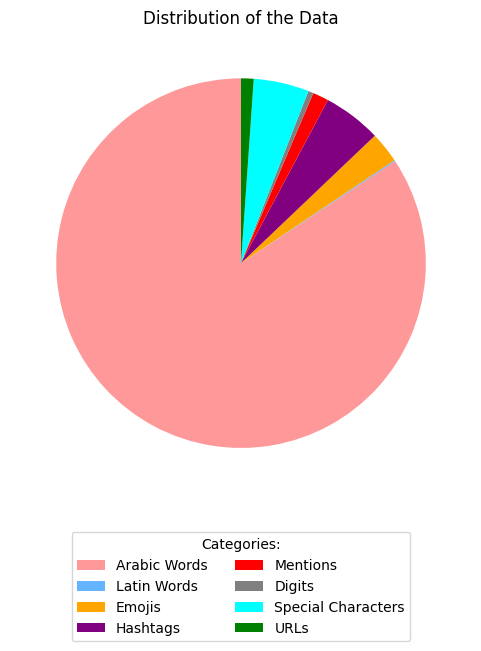

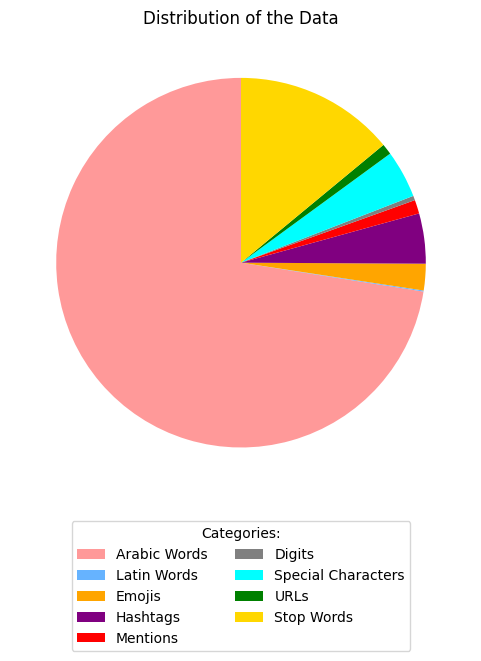

In [30]:
import re
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt

# Ensure 'words' is defined from the DataFrame
words = " ".join(df['Text'].astype(str)).split()

# Helper regex patterns
arabic_pattern = re.compile(r'^[\u0600-\u06FF]+$')
latin_pattern = re.compile(r'^[A-Za-z]+$')
emoji_pattern = re.compile("[\U00010000-\U0010ffff]", flags=re.UNICODE)
hashtag_pattern = re.compile(r'^#\w+')
mention_pattern = re.compile(r'^@\w+')
digit_pattern = re.compile(r'^\d+$')
special_pattern = re.compile(r'^[^\w\s]+$')

# Count Arabic words
total_arabic = sum(1 for w in words if arabic_pattern.match(w))
# Count Latin words
total_latin = sum(1 for w in words if latin_pattern.match(w))
# Extract emojis
emojis = [w for w in words if emoji_pattern.search(w)]
# Extract hashtags
hashtags = [w for w in words if hashtag_pattern.match(w)]
# Extract mentions
mentions = [w for w in words if mention_pattern.match(w)]
# Count digits
total_digits = sum(1 for w in words if digit_pattern.match(w))
# Count special characters (not alphanumeric, not whitespace)
total_specials = sum(1 for w in words if special_pattern.match(w))

# Combine all counts and labels into a single pie chart
all_labels = ['Arabic Words', 'Latin Words', 'Emojis', 'Hashtags', 'Mentions', 'Digits', 'Special Characters', 'URLs']
url_pattern = r'https?://\S+'
total_urls = len(re.findall(url_pattern, " ".join(words)))
all_counts = [total_arabic, total_latin, len(emojis), len(hashtags), len(mentions), total_digits, total_specials, total_urls]

import matplotlib.patches as mpatches
colors = ['#ff9999', '#66b3ff', 'orange', 'purple', 'red', 'gray', 'cyan', 'green']
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, all_labels)]
plt.figure(figsize=(7, 6))
patches, _ = plt.pie(all_counts, colors=colors, startangle=90)
plt.title("Distribution of the Data")
plt.legend(patches, all_labels, title="Categories:", loc="center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True, fancybox=True)
# print percentages 
for label, count in zip(all_labels, all_counts):
    percentage = (count / sum(all_counts)) * 100
    print(f"{label}: {percentage:.2f}%")

# Count stop words (Arabic) using nltk

try:
    arabic_stopwords = set(stopwords.words('arabic'))
except LookupError:
    nltk.download('stopwords')
    arabic_stopwords = set(stopwords.words('arabic'))

total_stopwords = sum(1 for w in words if w in arabic_stopwords)
print(f"Stop Words: {total_stopwords} ({(total_stopwords / len(words)) * 100:.2f}%)")


# Add stop words to the pie chart
all_labels.append('Stop Words')
all_counts.append(total_stopwords)
colors.append('#FFD700')  # gold for stop words

plt.figure(figsize=(7, 6))
patches, _ = plt.pie(all_counts, colors=colors, startangle=90)
plt.title("Distribution of the Data")
plt.legend(patches, all_labels, title="Categories:", loc="center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True, fancybox=True)
for label, count in zip(all_labels, all_counts):
    percentage = (count / sum(all_counts)) * 100
    print(f"{label}: {percentage:.2f}%")
plt.show()

Arabic Words: 85.57%

Latin Words: 6.39%

Emojis: 0.58%

Hashtags: 1.01%

Mentions: 0.27%

Digits: 1.17%

Special Characters: 5.01%






## 2.1 Data Collection and Preprocessing

### Dataset Description

The dataset used in this study, `train_araCovid_sentiment.tsv`, consists of 4,128 Arabic text comments collected from social media and review platforms. Each entry in the dataset contains:
- An index column (`Unnamed: 0`), which serves as a unique identifier for each row.
- The `Text` column, containing the actual user comment in Arabic. All comments are unique, with no duplicates present in the dataset.
- The `sentiment` column, which labels each comment as Positive, Negative, or Neutral.

**Key characteristics:**
- The dataset is clean, with no missing values in any column.
- Sentiment distribution is imbalanced: Neutral and Positive comments are almost equally represented (about 1,600 each), while Negative comments are less frequent (fewer than 1,000).
- The text length varies, with Neutral comments tending to be longer and more descriptive, while Positive and Negative comments are generally shorter.
- The dataset contains a wide vocabulary, with over 10,000 unique words.

This dataset provides a solid foundation for Arabic sentiment analysis, allowing for the exploration of class imbalance, text length variation, and vocabulary diversity in real-world user-generated content.

In [23]:
# Combine all comments into a single string
all_texts = " ".join(df['Text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
    
# Get unique words
corpus = set(words)

print("All unique words in the 'Text' column:")
print(corpus)

All unique words in the 'Text' column:
{'@bassam4071', 'حلّوا', 'شعلة', 'في', '#ههههههههههه🐸', 'https://t.co/jiJ0CfcYdP', 'اللهِ', 'تكون:', 'غاليتي', 'جاب', 'تقبيل...', 'الأجر', 'وأحفظنا', 'نبكي', 'عليك،', '#لصحتك', 'صرلن', 'مخلوقاتك', 'المشاوير', 'نعمر', '#البيضاء', 'ولكن', 'الإبتسامه', 'المختبرات', 'البلد', 'ترجع', 'كتار', 'وغرف', '@abdulrhmandohem', 'جحورها', 'وعاملين،', 'شنو؟', 'الفرج', 'ختمت', 'إحتاج', '✨💛روائع', '💬خلاص', 'الكوكايين"', 'مطلبنا', 'الذب', 'ليد', 'التضرع', 'يكفينا', '🧄🧄🧄', 'ومش', 'يحكم', 'ياجده', 'قبل', '@moi_algerie', '#مركز_أبوظبي_للخلايا_الجذعية', 'نجم', 'فصخي', '🤔', 'دراسة:', 'الفعالة', 'بعضنا👌🏻😁', 'وخافض', '#التيار_الوطني_الحر', 'خاصتنا', 'نتوما', 'فانتصر.', 'هايشة', '#كورونا_عميل', 'لايتبعها', 'مالها', 'المبارك', 'de', 'لرد', '#سنابات_غرفه_المعلمات', 'الظهر', 'لانها', 'اطباء', 'كورونا؟', 'ليخطئك}', 'تويتر:', 'مصابين', 'وتهريبهم', 'التالية،لتجنّب', 'جنينها', 'ومستني', 'للمواد', '😜😜😜', 'بِسْم', 'يضحكوا', 'نصائح...لتجنب', 'ترجى', '#YouAreResponsible', 'مِّن', '@Sa

In [24]:
len(corpus)

20510

In [20]:
from IPython.display import display, Markdown


table_md = "| Column | Original Text | Cleaned Text |\n|---|---|---|\n"
table_md += f"| 0 | {df['Text'].iloc[0]} | {df['cleaned_text'].iloc[0]} |\n"
table_md += f"| 4 | {df['Text'].iloc[4]} | {df['cleaned_text'].iloc[4]} |\n"
table_md += f"| 10 | {df['Text'].iloc[10]} | {df['cleaned_text'].iloc[10]} |\n"
table_md += f"| 20 | {df['Text'].iloc[20]} | {df['cleaned_text'].iloc[20]} |\n"
table_md += f"| 30 | {df['Text'].iloc[30]} | {df['cleaned_text'].iloc[30]} |\n"
table_md += f"| 40 | {df['Text'].iloc[40]} | {df['cleaned_text'].iloc[40]} |\n"
table_md += f"| 50 | {df['Text'].iloc[50]} | {df['cleaned_text'].iloc[50]} |\n"

display(Markdown(table_md))

KeyError: 'cleaned_text'

In [26]:
from nltk.corpus import stopwords
from IPython.display import display

# Function to clean text
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove hachtags
    text = re.sub(r'#\w+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text)
    # Remove numbers with 3 or more consecutive digits
    text = re.sub(r'\d{3,}', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove non-Arabic words
    text = re.sub(r'[^ا-ي\s]', '', text)
    # Remove stop words (Arabic) using nltk
    try:
        arabic_stopwords = set(stopwords.words('arabic'))
    except LookupError:
        nltk.download('stopwords')
        arabic_stopwords = set(stopwords.words('arabic'))
    text = ' '.join([word for word in text.split() if word not in arabic_stopwords])
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning function to the 'cleaned_text' column
df['cleaned_text'] = df['Text'].apply(clean_text)

# Remove rows with empty 'cleaned_text' after cleaning
df = df[df['cleaned_text'].str.strip() != '']

# Re-create the 'tokens' column from the cleaned text
import nltk
df['tokens'] = df['cleaned_text'].astype(str).apply(nltk.word_tokenize)

# Show original text, cleaned text, and tokens for selected rows
display(df.loc[[0, 4, 10], ['Text', 'cleaned_text', 'tokens']])

,Text,cleaned_text,tokens
0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,علاج ايروس الكورونا يوم الصبح الواحد يقرط ثلات...,"[علاج, ايروس, الكورونا, يوم, الصبح, الواحد, يق..."
4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,هههههههه انتظر تخلص كورونا عادي,"[هههههههه, انتظر, تخلص, كورونا, عادي]"
10,@hamedalhinai02 هههه بعد كورونا إن شاء الله ام...,هههه كورونا شا الله اما حاليا ملتزمين بالتباعد,"[هههه, كورونا, شا, الله, اما, حاليا, ملتزمين, ..."


In [28]:
# Combine all comments into a single string
all_texts = " ".join(df['cleaned_text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
	
# Get unique words
corpus = set(words)

print("All unique words in the 'cleaned_text' column:")
print(corpus)

All unique words in the 'cleaned_text' column:
{'دخلكن', 'سنعود', 'الزعيم', 'والجر', 'شعلة', 'ثر', 'تافه', 'وارحمه', 'بكي', 'والمساعدة', 'تاوعنا', 'ويصافحن', 'ويحتسبهم', 'كرونا', 'اسماعيل', 'ابد', 'غاليتي', 'السابق', 'جاب', 'وماهي', 'موديل', 'بالمستشفي', 'لله', 'ربع', 'نبكي', 'الشرق', 'صحتكم', 'وضعه', 'مروة', 'للشيخ', 'للصين', 'صرلن', 'مخلوقاتك', 'واسل', 'ماشفنا', 'قسمين', 'المشاوير', 'الضروف', 'لكابتن', 'متجاوزة', 'مخالطة', 'نواع', 'والعشر', 'بدات', 'يتى', 'الشكر', 'نعمر', 'اظن', 'استجب', 'مساكنهم', 'المنزل', 'استبشروا', 'ومبسوطين', 'المحافظة', 'المختبرات', 'المعتمرين', 'مزفت', 'نظامها', 'البلد', 'الواسعي', 'ترجع', 'كتار', 'ههههــههه', 'وغرف', 'ظهرت', 'وزملاه', 'انفسنا', 'جحورها', 'والوا', 'بتلى', 'زفت', 'الظروف', 'المسرطن', 'كجلب', 'جمع', 'اوكي', 'كونها', 'الظلم', 'هالايام', 'الفرج', 'الذراع', 'ختمت', 'بالقنطة', 'للمصلحة', 'يقولالمنتقبات', 'شعب', 'تضررت', 'السيل', 'الكابتن', 'كانا', 'دايما', 'ورحمة', 'الحواشين', 'مطلبنا', 'الذب', 'ليد', 'مرمطوناحسبي', 'التضرع', 'يكفينا', 'الحزم', 'هل

In [29]:
len(corpus)

12642

In [28]:
from IPython.display import display

# Tokenize the cleaned comments and add a new column
df['tokenized_text'] = df['cleaned_text'].astype(str).apply(nltk.word_tokenize)

# Display the cleaned_text and tokenized_text columns as a table
# Display the cleaned_text and tokenized_text columns as a table with wrapped text for better visibility
pd.set_option('display.max_colwidth', None)
display(df.loc[[0, 4, 10], ['Text', 'cleaned_text', 'tokenized_text']])
pd.reset_option('display.max_colwidth')

,Text,cleaned_text,tokenized_text
0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد يقرط ثلات حبات ثوم، ومع إنو الثوم ما إله علاقة بڤايروس الكورونا بس هكذا بتضمن لا حدا يقرب عليك ولا حدا يبوسك . 😅😅😅 😂😂😂 الله يبعد مننا ومنكم البلاء يارب,علاج ايروس الكورونا يوم الصبح الواحد يقرط ثلات حبات ثوم ومع نو الثوم علاقة بايروس الكورونا بتضمن حدا يقرب حدا يبوسك الله يبعد مننا ومنكم البلا يارب,"[علاج, ايروس, الكورونا, يوم, الصبح, الواحد, يقرط, ثلات, حبات, ثوم, ومع, نو, الثوم, علاقة, بايروس, الكورونا, بتضمن, حدا, يقرب, حدا, يبوسك, الله, يبعد, مننا, ومنكم, البلا, يارب]"
4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كورونا عادي 😂,هههههههه انتظر تخلص كورونا عادي,"[هههههههه, انتظر, تخلص, كورونا, عادي]"
10,@hamedalhinai02 هههه بعد كورونا إن شاء الله اما حالياً ملتزمين بالتباعد 😁👍🏻,هههه كورونا شا الله اما حاليا ملتزمين بالتباعد,"[هههه, كورونا, شا, الله, اما, حاليا, ملتزمين, بالتباعد]"


Arabic Words: 100.00%
Latin Words: 0.00%
Emojis: 0.00%
Hashtags: 0.00%
Mentions: 0.00%
Digits: 0.00%
Special Characters: 0.00%
URLs: 0.00%


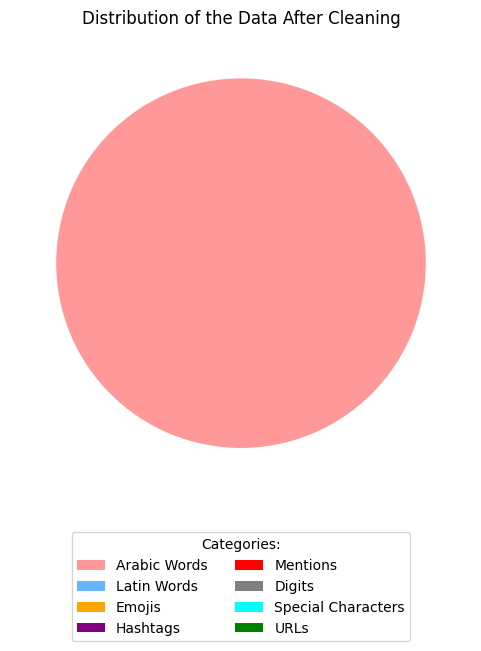

In [34]:
# Plot the distribution of Arabic, Latin, Emojis, Hashtags, Mentions, Digits, Special Characters, and URLs after cleaning

# Recalculate counts using the cleaned_text column
cleaned_words = " ".join(df['cleaned_text'].astype(str)).split()

# Arabic words
# Stop words (Arabic) using nltk
cleaned_stopwords = sum(1 for w in cleaned_words if w in arabic_stopwords)
cleaned_arabic = sum(1 for w in cleaned_words if arabic_pattern.match(w))
# Latin words
cleaned_latin = sum(1 for w in cleaned_words if latin_pattern.match(w))
# Emojis (should be very few or none after cleaning)
cleaned_emojis = [w for w in cleaned_words if emoji_pattern.search(w)]
# Hashtags
cleaned_hashtags = [w for w in cleaned_words if hashtag_pattern.match(w)]
# Mentions
cleaned_mentions = [w for w in cleaned_words if mention_pattern.match(w)]
# Digits
cleaned_digits = sum(1 for w in cleaned_words if digit_pattern.match(w))
# Special characters
cleaned_specials = sum(1 for w in cleaned_words if special_pattern.match(w))
# URLs
cleaned_urls = len(re.findall(url_pattern, " ".join(cleaned_words)))

cleaned_counts = [
    cleaned_arabic,
    cleaned_latin,
    len(cleaned_emojis),
    len(cleaned_hashtags),
    len(cleaned_mentions),
    cleaned_digits,
    cleaned_specials,
    cleaned_urls
]

plt.figure(figsize=(7, 6))
patches, _ = plt.pie(cleaned_counts, colors=colors, startangle=90)
plt.title("Distribution of the Data After Cleaning")
plt.legend(patches, all_labels, title="Categories:", loc="center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True, fancybox=True)
for label, count in zip(all_labels, cleaned_counts):
    percentage = (count / sum(cleaned_counts)) * 100 if sum(cleaned_counts) > 0 else 0
    print(f"{label}: {percentage:.2f}%")
plt.show()

In [1]:
# Combine all comments into a single string
all_texts = " ".join(df['cleaned_text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
	
# Get unique words
corpus = set(words)

print("All unique words in the 'cleaned_text' column:")
print(corpus)

NameError: name 'df' is not defined

In [ ]:
len(corpus)

12855